# NumPy Seq2Seq with GRU（完整訓練版 Notebook）

這份 Notebook 是根據你原始的 Seq2Seq / GRU 想法重新整理的完整版本。  
它的目標是：

- 保留 **NumPy from scratch**
- 補上 **可訓練** 的 Seq2Seq
- 使用 **GRU** 當 recurrent cell
- 提供 **完整 forward / backward / BPTT**
- 讓程式結構更清楚、便於教學與 debug

---

## 這份版本和你原始 GRU 的關係

你貼的 GRU 實作裡，數學核心方向是對的，但有幾個關鍵工程問題會導致它不能直接放進 Notebook 使用，例如：

- `forward_step()` 內直接引用 `Xs[t]`，但沒有傳入 `Xs` / `t`
- `backward()` 內使用 `Xs[0]`，但 `Xs` 沒有保存在類別裡
- GRU 本身把 output projection (`Wy`, `by`) 也包進去，不利於 Seq2Seq 解耦
- backward 只回傳參數梯度，不回傳 `dX` / `dH0`，不方便接 encoder / decoder
- 狀態保存分散在 `self.H`, `Hs`, `Ys`，很難驗證 shape 與梯度流

所以這份 Notebook 不是「直接照抄那份 GRU」，而是：

1. 保留你原本想實作的 **GRU 數學**
2. 改寫成比較乾淨的 **Seq2Seq 專用介面**
3. 補齊 **cache / backward / gradient flow**

如果你要對照原始碼看，最重要的概念對應是：

- `U` → update gate `z`
- `R` → reset gate `r`
- `H_tilda` → candidate hidden state `h_tilde`
- `H = U * H_pre + (1-U) * H_tilda` → 這裡我改寫成較常見的：
  `h = (1 - z) * h_prev + z * h_tilde`

兩種寫法本質相近，只是符號慣例不同。

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)

## 特殊 token 與數值工具

In [2]:
SOS_TOKEN = "<sos>"
EOS_TOKEN = "<eos>"

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def softmax(x):
    x = x - np.max(x)
    e = np.exp(x)
    return e / np.sum(e)

def cross_entropy_and_grad(logits, target_idx):
    probs = softmax(logits)
    loss = -np.log(probs[target_idx] + 1e-12)

    grad = probs.copy()
    grad[target_idx] -= 1.0
    return loss, grad

## 字元詞彙表

這裡採用 character-level 翻譯，方便觀察 one-hot、GRU、BPTT 的資料流。

In [3]:
class CharVocab:
    def __init__(self, texts):
        chars = sorted(set("".join(texts)))

        self.char2idx = {
            SOS_TOKEN: 0,
            EOS_TOKEN: 1,
        }

        next_idx = 2
        for ch in chars:
            if ch not in self.char2idx:
                self.char2idx[ch] = next_idx
                next_idx += 1

        self.idx2char = {idx: ch for ch, idx in self.char2idx.items()}
        self.sos_id = self.char2idx[SOS_TOKEN]
        self.eos_id = self.char2idx[EOS_TOKEN]
        self.size = len(self.char2idx)

    def encode(self, text, add_eos=True):
        ids = [self.char2idx[ch] for ch in text]
        if add_eos:
            ids.append(self.eos_id)
        return np.array(ids, dtype=np.int64)

    def decode(self, ids, stop_at_eos=True):
        chars = []
        for idx in ids:
            idx = int(idx)
            if stop_at_eos and idx == self.eos_id:
                break
            if idx == self.sos_id:
                continue
            chars.append(self.idx2char[idx])
        return "".join(chars)

## 小型英法資料集

資料很小，但足以讓模型確實學到對應關係。  
Notebook 的重點是完整可理解的 GRU Seq2Seq，而不是大規模翻譯品質。

In [4]:
pairs = [
    ("i am cold", "j ai froid"),
    ("i am warm", "j ai chaud"),
    ("i am happy", "je suis heureux"),
    ("i am sad", "je suis triste"),
    ("he is tall", "il est grand"),
    ("he is short", "il est petit"),
    ("she is kind", "elle est gentille"),
    ("she is ready", "elle est prete"),
    ("you are nice", "tu es gentil"),
    ("you are late", "tu es en retard"),
    ("we are ready", "nous sommes prets"),
    ("we are tired", "nous sommes fatigues"),
    ("they are here", "ils sont ici"),
    ("they are busy", "ils sont occupes"),
    ("hello", "bonjour"),
    ("good night", "bonne nuit"),
    ("thank you", "merci"),
    ("see you", "a bientot"),
    ("i love you", "je t aime"),
    ("how are you", "comment ca va"),
]

src_vocab = CharVocab([src for src, _ in pairs])
tgt_vocab = CharVocab([tgt for _, tgt in pairs])

dataset = [(src_vocab.encode(src), tgt_vocab.encode(tgt)) for src, tgt in pairs]

print("Number of pairs:", len(dataset))
print("Source vocab size:", src_vocab.size)
print("Target vocab size:", tgt_vocab.size)
print("Example:")
print("  src:", pairs[0][0], "->", dataset[0][0])
print("  tgt:", pairs[0][1], "->", dataset[0][1])

Number of pairs: 20
Source vocab size: 24
Target vocab size: 24
Example:
  src: i am cold -> [10  2  3 13  2  5 15 12  6  1]
  tgt: j ai froid -> [12  2  3 11  2  8 18 16 11  6  1]


## 單層 GRU（NumPy 手刻）

這裡把 GRU 做成比較適合 Seq2Seq 的介面：

### forward
輸入：
- `xs`: `(T, input_dim)`
- `h0`: `(hidden_dim,)`

輸出：
- `hs`: `(T, hidden_dim)`
- `cache`: backward 所需資訊

### backward
輸入：
- `dhs`: `(T, hidden_dim)`，每個 timestep hidden 的外部梯度
- `cache`

輸出：
- `dxs`: `(T, input_dim)`
- `dh0`: 初始 hidden state 的梯度

這樣 decoder 的 `dh0` 就可以直接接回 encoder 最後 hidden。

In [5]:
class GRULayer:
    def __init__(self, input_dim, hidden_dim, seed=42, scale=0.08):
        rng = np.random.default_rng(seed)

        self.input_dim = input_dim
        self.hidden_dim = hidden_dim

        # update gate z
        self.Wxz = rng.normal(0, scale, (hidden_dim, input_dim))
        self.Whz = rng.normal(0, scale, (hidden_dim, hidden_dim))
        self.bz = np.zeros(hidden_dim)

        # reset gate r
        self.Wxr = rng.normal(0, scale, (hidden_dim, input_dim))
        self.Whr = rng.normal(0, scale, (hidden_dim, hidden_dim))
        self.br = np.zeros(hidden_dim)

        # candidate hidden h_tilde
        self.Wxh = rng.normal(0, scale, (hidden_dim, input_dim))
        self.Whh = rng.normal(0, scale, (hidden_dim, hidden_dim))
        self.bh = np.zeros(hidden_dim)

        self.zero_grads()

    def zero_grads(self):
        self.dWxz = np.zeros_like(self.Wxz)
        self.dWhz = np.zeros_like(self.Whz)
        self.dbz = np.zeros_like(self.bz)

        self.dWxr = np.zeros_like(self.Wxr)
        self.dWhr = np.zeros_like(self.Whr)
        self.dbr = np.zeros_like(self.br)

        self.dWxh = np.zeros_like(self.Wxh)
        self.dWhh = np.zeros_like(self.Whh)
        self.dbh = np.zeros_like(self.bh)

    def step(self, lr):
        self.Wxz -= lr * self.dWxz
        self.Whz -= lr * self.dWhz
        self.bz  -= lr * self.dbz

        self.Wxr -= lr * self.dWxr
        self.Whr -= lr * self.dWhr
        self.br  -= lr * self.dbr

        self.Wxh -= lr * self.dWxh
        self.Whh -= lr * self.dWhh
        self.bh  -= lr * self.dbh

    def clip_grads(self, scale):
        self.dWxz *= scale
        self.dWhz *= scale
        self.dbz *= scale

        self.dWxr *= scale
        self.dWhr *= scale
        self.dbr *= scale

        self.dWxh *= scale
        self.dWhh *= scale
        self.dbh *= scale

    def forward(self, xs, h0=None):
        T = xs.shape[0]
        H = self.hidden_dim

        if h0 is None:
            h_prev = np.zeros(H)
        else:
            h_prev = h0.copy()

        hs = np.zeros((T, H))
        cache = []

        for t in range(T):
            x = xs[t]

            az = self.Wxz @ x + self.Whz @ h_prev + self.bz
            ar = self.Wxr @ x + self.Whr @ h_prev + self.br

            z = sigmoid(az)
            r = sigmoid(ar)

            ah = self.Wxh @ x + self.Whh @ (r * h_prev) + self.bh
            h_tilde = np.tanh(ah)

            h = (1.0 - z) * h_prev + z * h_tilde

            hs[t] = h
            cache.append({
                "x": x,
                "h_prev": h_prev,
                "z": z,
                "r": r,
                "h_tilde": h_tilde,
                "h": h,
            })

            h_prev = h

        return hs, cache

    def backward(self, dhs, cache):
        T = len(cache)
        dxs = np.zeros((T, self.input_dim))
        dh_next = np.zeros(self.hidden_dim)

        self.zero_grads()

        for t in reversed(range(T)):
            c = cache[t]

            x = c["x"]
            h_prev = c["h_prev"]
            z = c["z"]
            r = c["r"]
            h_tilde = c["h_tilde"]

            dh = dhs[t] + dh_next

            dz = dh * (h_tilde - h_prev)
            dh_tilde = dh * z
            dh_prev = dh * (1.0 - z)

            dah = dh_tilde * (1.0 - h_tilde**2)

            self.dWxh += np.outer(dah, x)
            self.dWhh += np.outer(dah, r * h_prev)
            self.dbh += dah

            dx_from_h = self.Wxh.T @ dah
            dr_hprev = self.Whh.T @ dah

            dr = dr_hprev * h_prev
            dh_prev += dr_hprev * r

            dar = dr * r * (1.0 - r)

            self.dWxr += np.outer(dar, x)
            self.dWhr += np.outer(dar, h_prev)
            self.dbr += dar

            dx_from_r = self.Wxr.T @ dar
            dh_prev += self.Whr.T @ dar

            daz = dz * z * (1.0 - z)

            self.dWxz += np.outer(daz, x)
            self.dWhz += np.outer(daz, h_prev)
            self.dbz += daz

            dx_from_z = self.Wxz.T @ daz
            dh_prev += self.Whz.T @ daz

            dxs[t] = dx_from_h + dx_from_r + dx_from_z
            dh_next = dh_prev

        dh0 = dh_next
        return dxs, dh0

## Seq2Seq with GRU

In [6]:
class Seq2SeqGRUNumpy:
    def __init__(self, src_vocab_size, tgt_vocab_size, hidden_size=64, seed=42):
        self.src_vocab_size = src_vocab_size
        self.tgt_vocab_size = tgt_vocab_size
        self.hidden_size = hidden_size

        self.encoder = GRULayer(src_vocab_size, hidden_size, seed=seed)
        self.decoder = GRULayer(tgt_vocab_size, hidden_size, seed=seed + 1)

        rng = np.random.default_rng(seed + 2)
        scale = 0.08
        self.Wo = rng.normal(0, scale, (tgt_vocab_size, hidden_size))
        self.bo = np.zeros(tgt_vocab_size)

        self.zero_grads()

    def zero_grads(self):
        self.encoder.zero_grads()
        self.decoder.zero_grads()
        self.dWo = np.zeros_like(self.Wo)
        self.dbo = np.zeros_like(self.bo)

    def one_hot_seq(self, ids, vocab_size):
        xs = np.zeros((len(ids), vocab_size))
        for t, idx in enumerate(ids):
            xs[t, int(idx)] = 1.0
        return xs

    def clip_grads(self, max_norm=1.0):
        total_norm_sq = 0.0

        grads = [
            self.encoder.dWxz, self.encoder.dWhz, self.encoder.dbz,
            self.encoder.dWxr, self.encoder.dWhr, self.encoder.dbr,
            self.encoder.dWxh, self.encoder.dWhh, self.encoder.dbh,
            self.decoder.dWxz, self.decoder.dWhz, self.decoder.dbz,
            self.decoder.dWxr, self.decoder.dWhr, self.decoder.dbr,
            self.decoder.dWxh, self.decoder.dWhh, self.decoder.dbh,
            self.dWo, self.dbo,
        ]

        for g in grads:
            total_norm_sq += np.sum(g ** 2)

        total_norm = np.sqrt(total_norm_sq)

        if total_norm > max_norm:
            scale = max_norm / (total_norm + 1e-8)
            self.encoder.clip_grads(scale)
            self.decoder.clip_grads(scale)
            self.dWo *= scale
            self.dbo *= scale

        return total_norm

    def step(self, lr=0.1):
        self.encoder.step(lr)
        self.decoder.step(lr)
        self.Wo -= lr * self.dWo
        self.bo -= lr * self.dbo

    def forward(self, src_ids, tgt_ids, teacher_forcing=True):
        enc_xs = self.one_hot_seq(src_ids, self.src_vocab_size)
        enc_hs, enc_cache = self.encoder.forward(enc_xs, h0=None)
        enc_last = enc_hs[-1]

        dec_input_ids = [0]
        if teacher_forcing:
            dec_input_ids.extend(list(tgt_ids[:-1]))
        else:
            raise NotImplementedError("Training 這裡先只支援 teacher_forcing=True，推論請用 translate().")

        dec_xs = self.one_hot_seq(dec_input_ids, self.tgt_vocab_size)
        dec_hs, dec_cache = self.decoder.forward(dec_xs, h0=enc_last)

        logits_list = []
        loss = 0.0

        for t, target_idx in enumerate(tgt_ids):
            logits = self.Wo @ dec_hs[t] + self.bo
            logits_list.append(logits)

            step_loss, _ = cross_entropy_and_grad(logits, int(target_idx))
            loss += step_loss

        avg_loss = loss / len(tgt_ids)

        cache = {
            "src_ids": src_ids,
            "tgt_ids": tgt_ids,
            "enc_hs": enc_hs,
            "enc_cache": enc_cache,
            "enc_last": enc_last,
            "dec_input_ids": np.array(dec_input_ids, dtype=np.int64),
            "dec_hs": dec_hs,
            "dec_cache": dec_cache,
            "logits_list": logits_list,
        }

        return avg_loss, cache

    def backward(self, cache):
        self.zero_grads()

        tgt_ids = cache["tgt_ids"]
        dec_hs = cache["dec_hs"]
        logits_list = cache["logits_list"]
        dec_cache = cache["dec_cache"]
        enc_cache = cache["enc_cache"]

        T_dec = len(tgt_ids)
        d_dec_hs = np.zeros_like(dec_hs)

        for t in range(T_dec):
            logits = logits_list[t]
            target_idx = int(tgt_ids[t])

            _, dlogits = cross_entropy_and_grad(logits, target_idx)
            dlogits /= T_dec

            self.dWo += np.outer(dlogits, dec_hs[t])
            self.dbo += dlogits

            d_dec_hs[t] += self.Wo.T @ dlogits

        _, d_enc_last = self.decoder.backward(d_dec_hs, dec_cache)

        d_enc_hs = np.zeros((len(enc_cache), self.hidden_size))
        d_enc_hs[-1] = d_enc_last

        self.encoder.backward(d_enc_hs, enc_cache)

    def translate_ids(self, src_ids, max_len=80, sos_id=0, eos_id=1):
        enc_xs = self.one_hot_seq(src_ids, self.src_vocab_size)
        enc_hs, _ = self.encoder.forward(enc_xs, h0=None)
        h = enc_hs[-1]

        output_ids = []
        input_id = sos_id

        for _ in range(max_len):
            x = np.zeros(self.tgt_vocab_size)
            x[input_id] = 1.0

            dec_hs, _ = self.decoder.forward(x.reshape(1, -1), h0=h)
            h = dec_hs[0]

            logits = self.Wo @ h + self.bo
            pred = int(np.argmax(logits))
            output_ids.append(pred)

            if pred == eos_id:
                break

            input_id = pred

        return output_ids

    def translate_text(self, text, src_vocab, tgt_vocab, max_len=80):
        src_ids = src_vocab.encode(text)
        pred_ids = self.translate_ids(
            src_ids=src_ids,
            max_len=max_len,
            sos_id=tgt_vocab.sos_id,
            eos_id=tgt_vocab.eos_id,
        )
        return tgt_vocab.decode(pred_ids)

## 訓練函式

In [7]:
def train_model(
    model,
    dataset,
    epochs=700,
    lr=0.08,
    grad_clip=1.0,
    print_every=50,
):
    losses = []

    for epoch in range(1, epochs + 1):
        random.shuffle(dataset)
        total_loss = 0.0

        for src_ids, tgt_ids in dataset:
            loss, cache = model.forward(
                src_ids=src_ids,
                tgt_ids=tgt_ids,
                teacher_forcing=True,
            )
            model.backward(cache)
            model.clip_grads(grad_clip)
            model.step(lr)

            total_loss += loss

        avg_loss = total_loss / len(dataset)
        losses.append(avg_loss)

        if epoch % print_every == 0 or epoch == 1:
            print(f"Epoch {epoch:4d} | avg_loss = {avg_loss:.4f}")

    return losses

## 開始訓練

In [8]:
model = Seq2SeqGRUNumpy(
    src_vocab_size=src_vocab.size,
    tgt_vocab_size=tgt_vocab.size,
    hidden_size=64,
    seed=42,
)

losses = train_model(
    model=model,
    dataset=dataset,
    epochs=700,
    lr=0.08,
    grad_clip=1.0,
    print_every=50,
)

Epoch    1 | avg_loss = 3.1555
Epoch   50 | avg_loss = 2.2642
Epoch  100 | avg_loss = 1.5605
Epoch  150 | avg_loss = 1.0663
Epoch  200 | avg_loss = 0.6423
Epoch  250 | avg_loss = 0.4005
Epoch  300 | avg_loss = 0.2368
Epoch  350 | avg_loss = 0.1257
Epoch  400 | avg_loss = 0.0582
Epoch  450 | avg_loss = 0.0285
Epoch  500 | avg_loss = 0.0211
Epoch  550 | avg_loss = 0.0116
Epoch  600 | avg_loss = 0.0086
Epoch  650 | avg_loss = 0.0068
Epoch  700 | avg_loss = 0.0056


## 觀察訓練 loss

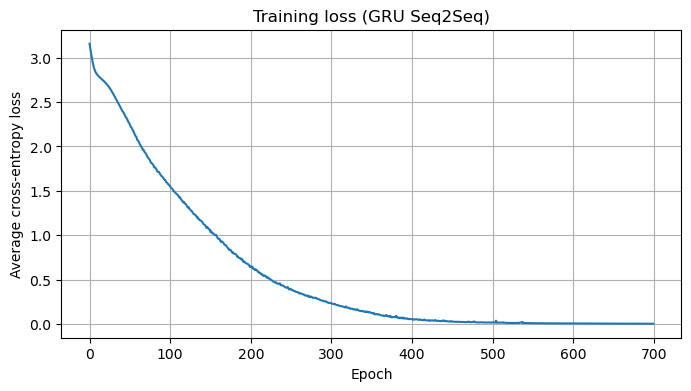

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.title("Training loss (GRU Seq2Seq)")
plt.xlabel("Epoch")
plt.ylabel("Average cross-entropy loss")
plt.grid(True)
plt.show()

## 檢查訓練集翻譯結果

In [10]:
for src_text, tgt_text in pairs:
    pred_text = model.translate_text(src_text, src_vocab, tgt_vocab)
    print(f"SRC : {src_text}")
    print(f"TGT : {tgt_text}")
    print(f"PRED: {pred_text}")
    print("-" * 50)

SRC : i am cold
TGT : j ai froid
PRED: j ai froid
--------------------------------------------------
SRC : i am warm
TGT : j ai chaud
PRED: j ai chaud
--------------------------------------------------
SRC : i am happy
TGT : je suis heureux
PRED: je suis heureux
--------------------------------------------------
SRC : i am sad
TGT : je suis triste
PRED: je suis triste
--------------------------------------------------
SRC : he is tall
TGT : il est grand
PRED: il est grand
--------------------------------------------------
SRC : he is short
TGT : il est petit
PRED: il est petit
--------------------------------------------------
SRC : she is kind
TGT : elle est gentille
PRED: elle est gentille
--------------------------------------------------
SRC : she is ready
TGT : elle est prete
PRED: elle est prete
--------------------------------------------------
SRC : you are nice
TGT : tu es gentil
PRED: tu es gentil
--------------------------------------------------
SRC : you are late
TGT : tu 

## 測幾個輸入

In [11]:
tests = [
    "i am cold",
    "i am warm",
    "he is tall",
    "thank you",
    "good night",
    "hello",
]

for text in tests:
    pred = model.translate_text(text, src_vocab, tgt_vocab)
    print(f"{text:>12s}  ->  {pred}")

   i am cold  ->  j ai froid
   i am warm  ->  j ai chaud
  he is tall  ->  il est grand
   thank you  ->  merci
  good night  ->  bonne nuit
       hello  ->  bonjour


## 與你原始 GRU 實作的主要差異

### 1. GRU 本體不處理 output layer
你原始版本把 `Wy`, `by` 也放進 GRU 類別。  
這份版本改成：

- `GRULayer` 只負責 hidden transition
- `Seq2SeqGRUNumpy` 額外負責 output projection `Wo`, `bo`

### 2. backward 會回傳 `dxs` 與 `dh0`
這是 Seq2Seq 能串起來的關鍵。  
decoder 的 `dh0` 就是 encoder 最後 hidden 的梯度。

### 3. cache 完整保存
BPTT 需要每個 timestep 的：
- `x`
- `h_prev`
- `z`
- `r`
- `h_tilde`

所以這裡統一存在 `cache`，而不是零散掛在多個 `self.xxx`。

### 4. 訓練與推論分離
訓練用 teacher forcing。  
推論用 autoregressive decoding。  
這比把兩種模式混在同一條 forward 裡更容易除錯。

## GRU Forward（數學推導）

給定輸入 $x_t$ 與前一時刻 hidden state $h_{t-1}$，GRU 的計算如下：

### 1️⃣ Update Gate（更新門）

$$
z_t = \sigma(W_z x_t + U_z h_{t-1} + b_z)
$$

---

### 2️⃣ Reset Gate（重置門）

$$
r_t = \sigma(W_r x_t + U_r h_{t-1} + b_r)
$$

---

### 3️⃣ Candidate Hidden State（候選隱狀態）

$$
\tilde{h}_t = \tanh(W_h x_t + U_h (r_t \odot h_{t-1}) + b_h)
$$

---

### 4️⃣ Hidden State 更新

$$
h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t
$$

---

### 📌 直觀解釋

- $z_t$：決定「保留舊資訊 vs 更新新資訊」
- $r_t$：決定「舊 hidden 有多少參與新候選」
- $\tilde{h}_t$：新的候選記憶
- $h_t$：融合舊記憶與新記憶

# Seq2Seq 數學流程（高中數學版拆解）

---

# 一、Encoder：把輸入序列壓縮成一個向量

## 1. 輸入序列

給定一串輸入：

$$
x_1, x_2, ..., x_T
$$

每個 $x_t$ 可以理解為一個數字向量，例如：

$$
x_t = [x_1, x_2, ..., x_d]
$$

---

## 2. 狀態更新（簡化 GRU 理解）

原始形式：

$$
h_t^{enc} = \text{GRU}(x_t, h_{t-1}^{enc})
$$

可以用高中數學理解為：

$$
h_t = f(x_t, h_{t-1})
$$

也就是：

> 新狀態 = 某個函數(目前輸入 + 前一個狀態)

---

## 3. GRU 的核心（加權平均概念）

可以近似理解為：

$$
h_t = u_t \cdot h_{t-1} + (1 - u_t) \cdot \tilde{h}_t
$$

其中：

- $u_t \in [0,1]$：權重
- $\tilde{h}_t$：新的候選資訊

這其實是一種「加權平均」：

$$
\text{新狀態} = \text{保留舊資訊} + \text{加入新資訊}
$$

---

## 4. 最終輸出（context vector）

$$
c = h_T^{enc}
$$

意思是：

> 把整個序列壓縮成最後一個向量 $c$

---

# 二、Decoder：從向量生成輸出序列

---

## 1. 初始化

$$
h_0^{dec} = c
$$

---

## 2. 狀態更新

$$
h_t^{dec} = \text{GRU}(y_{t-1}, h_{t-1}^{dec})
$$

高中理解：

$$
h_t = f(y_{t-1}, h_{t-1})
$$

---

## 3. 線性轉換（矩陣乘法）

$$
o_t = W_o h_t + b_o
$$

展開形式：

$$
o_t =
\begin{bmatrix}
w_{11} & w_{12} \\
w_{21} & w_{22}
\end{bmatrix}
\begin{bmatrix}
h_1 \\
h_2
\end{bmatrix}
+
\begin{bmatrix}
b_1 \\
b_2
\end{bmatrix}
$$

---

## 4. softmax（轉換成機率）

$$
p_t = \text{softmax}(o_t)
$$

計算方式：

$$
p_i = \frac{e^{o_i}}{\sum_j e^{o_j}}
$$

性質：

- 每個值 > 0
- 總和 = 1

---

# 三、Loss（交叉熵）

---

## 1. 總損失

$$
L = - \sum_{t=1}^{T'} \log p_t(y_t)
$$

---

## 2. 單一步驟的意義

$$
\log p_t(y_t)
$$

代表：

> 模型對「正確答案」給的機率

---

## 3. 為什麼加負號？

因為：

- 若 $p \approx 1$：
  $$
  \log(1) = 0
  $$

- 若 $p \approx 0$：
  $$
  \log(p) \ll 0
  $$

因此：

$$
-\log(p)
$$

具有：

- 機率越大 → 損失越小
- 機率越小 → 損失越大

---

## 4. 平均損失

$$
L = \frac{1}{T'} \sum_{t=1}^{T'} -\log p_t(y_t)
$$

---

# 四、整體流程總結

---

## Encoder（壓縮）

$$
(x_1, x_2, ..., x_T)
\rightarrow h_1 \rightarrow h_2 \rightarrow ... \rightarrow h_T = c
$$

---

## Decoder（生成）

$$
c \rightarrow h_1 \rightarrow h_2 \rightarrow ... \rightarrow y_1, y_2, ...
$$

---

## Loss（評估）

$$
\text{預測機率} \rightarrow \text{與正確答案比較} \rightarrow \text{計算損失}
$$

# GRU Backward（反向傳播，高中數學版拆解）

---

# 一、從 Hidden State 開始反傳

## 1. Hidden State 的組成

GRU 的 hidden state：

$$
h_t = (1 - z_t) h_{t-1} + z_t \tilde{h}_t
$$

這其實是一個「加權平均」：

$$
\text{新狀態} = \text{保留舊資訊} + \text{加入新資訊}
$$

---

## 2. 梯度拆解（核心）

假設我們已經有：

$$
d h_t = \frac{\partial L}{\partial h_t}
$$

---

### (1) 對 $z_t$ 的影響

因為：

$$
h_t = (1 - z_t) h_{t-1} + z_t \tilde{h}_t
$$

對 $z_t$ 微分（高中乘法微分概念）：

$$
\frac{\partial h_t}{\partial z_t} = \tilde{h}_t - h_{t-1}
$$

因此：

$$
d z_t = d h_t \odot (\tilde{h}_t - h_{t-1})
$$

---

### (2) 對 $\tilde{h}_t$ 的影響

$$
\frac{\partial h_t}{\partial \tilde{h}_t} = z_t
$$

所以：

$$
d \tilde{h}_t = d h_t \odot z_t
$$

---

### (3) 對前一個 hidden 的影響

$$
\frac{\partial h_t}{\partial h_{t-1}} = (1 - z_t)
$$

因此：

$$
d h_{t-1} += d h_t \odot (1 - z_t)
$$

---

# 二、Candidate Hidden 的梯度

---

## 1. 定義

$$
\tilde{h}_t = \tanh(a_h)
$$

---

## 2. tanh 的微分（高中可理解）

$$
\frac{d}{dx} \tanh(x) = 1 - \tanh^2(x)
$$

因此：

$$
d a_h = d \tilde{h}_t \odot (1 - \tilde{h}_t^2)
$$

---

# 三、Reset Gate 的影響

---

## 1. 線性組合

$$
a_h = W_h x_t + U_h (r_t \odot h_{t-1}) + b_h
$$

---

## 2. 對 $r_t$ 的梯度

觀察：

$$
U_h (r_t \odot h_{t-1})
$$

這裡是「逐元素乘法」再做線性變換。

---

### Step 1：先對乘積微分

$$
\frac{\partial (r_t \odot h_{t-1})}{\partial r_t} = h_{t-1}
$$

---

### Step 2：再乘上矩陣轉置（鏈式法則）

$$
d r_t = (U_h^T d a_h) \odot h_{t-1}
$$

---

## 3. 對 $h_{t-1}$ 的額外影響

同樣來自：

$$
r_t \odot h_{t-1}
$$

因此：

$$
d h_{t-1} += (U_h^T d a_h) \odot r_t
$$

---

# 四、Sigmoid 的梯度

---

## 1. Update Gate

$$
z_t = \sigma(a_z)
$$

Sigmoid 微分：

$$
\frac{d}{dx} \sigma(x) = \sigma(x)(1 - \sigma(x))
$$

所以：

$$
d a_z = d z_t \odot z_t (1 - z_t)
$$

---

## 2. Reset Gate

同理：

$$
d a_r = d r_t \odot r_t (1 - r_t)
$$

---

# 五、梯度傳回前一時間點

---

## 1. 來自 gate 的影響

因為：

- $a_z = W_z x_t + U_z h_{t-1}$
- $a_r = W_r x_t + U_r h_{t-1}$

---

## 2. 對 $h_{t-1}$ 的貢獻

由鏈式法則：

$$
d h_{t-1} += U_z^T d a_z + U_r^T d a_r
$$

---

# 六、整體梯度流總結

---

在時間 $t$：

$$
d h_t
\rightarrow (z_t, \tilde{h}_t, h_{t-1})
\rightarrow (a_h, a_z, a_r)
\rightarrow h_{t-1}
$$

---

## 關鍵觀念（高中版）

1. 每一個式子本質都是：
   $$
   y = ax + b
   $$
   或
   $$
   y = x_1 \cdot x_2
   $$

2. 反向傳播就是：
   > 一層一層把影響「拆回去」

3. 每個 gate 的作用：
   - $z_t$：控制「保留 vs 更新」
   - $r_t$：控制「是否看過去」

---

# 如果你要再進一步

可以做三個強化版本：

1. 🔁 對照 NumPy 實作（逐行對應）
2. 📊 畫出完整計算圖（computation graph）
3. 🧠 用「訊號流」方式重新解釋梯度

直接說你要哪一種

## Seq2Seq Gradient Flow（非常重要）

整個梯度傳遞順序如下：

### Step 1：Output layer

$$
d h_t^{dec} = W_o^T d o_t
$$

---

### Step 2：Decoder BPTT

$$
d h_{t-1}^{dec} = GRU\_backward(d h_t^{dec})
$$

---

### Step 3：Encoder ← Decoder

Decoder 初始 hidden：

$$
h_0^{dec} = h_T^{enc}
$$

因此：

$$
d h_T^{enc} = d h_0^{dec}
$$

---

### Step 4：Encoder BPTT

$$
d h_{t-1}^{enc} = GRU\_backward(d h_t^{enc})
$$

---

### 📌 核心觀念

👉 **Encoder 和 Decoder 是透過 hidden state 串起來的**

👉 梯度會：


# Teacher Forcing（教師強制，Seq2Seq 訓練技巧）

---

# 一、基本概念

在 Decoder 中，每一步都需要一個輸入：

$$
x_t^{dec}
$$

這個輸入其實就是「上一個時間點的輸出」。

---

# 二、兩種做法

---

## 1. 使用模型自己的預測（一般情況）

$$
x_t^{dec} = \hat{y}_{t-1}
$$

其中：

- $\hat{y}_{t-1}$：模型預測的結果

👉 流程：

$$
\hat{y}_1 \rightarrow \hat{y}_2 \rightarrow \hat{y}_3 \rightarrow ...
$$

---

## 2. Teacher Forcing（訓練時使用）

$$
x_t^{dec} = y_{t-1}^{(ground\ truth)}
$$

其中：

- $y_{t-1}^{(ground\ truth)}$：正確答案

👉 流程：

$$
y_1^{(true)} \rightarrow y_2^{(true)} \rightarrow y_3^{(true)} \rightarrow ...
$$

---

# 三、為什麼要用 Teacher Forcing？

---

## 1. 減少誤差累積（Error Accumulation）

如果使用模型自己的預測：

$$
x_t^{dec} = \hat{y}_{t-1}
$$

當某一步錯誤：

$$
\hat{y}_{t-1} \neq y_{t-1}
$$

就會導致：

$$
x_t^{dec} \text{ 錯誤} \Rightarrow \hat{y}_t \text{ 更容易錯}
$$

👉 誤差會「一層一層放大」

---

## 2. Teacher Forcing 的效果

使用：

$$
x_t^{dec} = y_{t-1}^{(ground\ truth)}
$$

每一步輸入都是正確的，因此：

- 不會受到前一步錯誤影響
- 梯度更穩定

---

## 3. 加速收斂

因為輸入是正確的：

$$
\text{學習目標} = \text{乾淨訊號}
$$

👉 模型比較容易學到正確 mapping

---

## 4. 穩定訓練

避免以下情況：

$$
\hat{y}_{t-1} \rightarrow \text{錯誤} \rightarrow \text{梯度混亂}
$$

---

# 四、推論（Inference）時

---

訓練結束後，沒有正確答案可以用，因此只能用模型自己的輸出：

$$
x_t^{dec} = \arg\max p_{t-1}
$$

---

## 解釋

如果：

$$
p_{t-1} = [0.1, 0.7, 0.2]
$$

則：

$$
\arg\max p_{t-1} = \text{第 2 類}
$$

👉 就選機率最大的當作下一步輸入

---

# 五、整體對照

---

## 訓練（Training）

$$
x_t^{dec} = y_{t-1}^{(true)}
$$

👉 使用正確答案

---

## 推論（Inference）

$$
x_t^{dec} = \hat{y}_{t-1} = \arg\max p_{t-1}
$$

👉 使用模型預測

---

# 六、核心觀念總結（高中版）

---

1. Decoder 本質是：

$$
\text{下一步} = f(\text{上一個輸出})
$$

---

2. Teacher Forcing 的本質：

$$
\text{把「上一個輸出」換成「正確答案」}
$$

---

3. 影響：

- 減少錯誤連鎖
- 讓學習更單純
- 讓梯度更穩定

---

# 七、進一步延伸（如果你要更深入）

---

可以再延伸三個重要主題：

1. 📉 Exposure Bias（訓練與測試不一致）
2. 🔄 Scheduled Sampling（部分使用預測）
3. 🧠 和 Cross Entropy 的關係（為什麼這樣餵資料是合理的）

直接告訴我你要哪一個